In [1]:
!pip install pydub
!sudo apt install ffmpeg
!pip install uvicorn[standard]
!pip install langchain-core
!pip install -qU langchain-groq
!pip install python-multipart
!pip install gdown
!pip install diffusers
!pip install Pillow
!pip install ultralytics==8.3.39
# !pip install colabcode


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 72 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.1/415.1 kB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.7/335.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 21.3
    Uninstalling packaging-21.3:
      Successfully uninstalled packaging-21.3
  Attempting uninstall: requests-toolbelt
    Found existing installation: requests-toolbelt 0.10.1
    Uninstalling requests-toolbelt-0.10.1:
      Successfully uninstalled requests-toolbelt-0.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages t

In [2]:
!pip install fastapi
!pip install pyngrok


In [3]:
# import gdown
# # url = 'https://drive.google.com/uc?id=1uHjzo7eEOnm93BeDA7MEQTc1MGhNzdLA'
# url = 'https://drive.google.com/drive/folders/1-0-QWTZkcHzDaFWhoOHIiY5J0dK4fc13'
# output = 'pytorch_lora_weights.safetensors'
# gdown.download(url, output, quiet=False)

In [4]:
from pyngrok import ngrok

ngrok.install_ngrok()

In [5]:
!pip install git+https://github.com/huggingface/diffusers.git -q

In [6]:
!pip install bitsandbytes transformers accelerate peft -q

In [7]:
!pip install git+https://github.com/huggingface/peft.git

  Cloning https://github.com/huggingface/peft.git to /tmp/pip-req-build-hrqisg9c
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft.git /tmp/pip-req-build-hrqisg9c
  Resolved https://github.com/huggingface/peft.git to commit 24150d0e41fa8a6fc998980e73a96dede0b33ffc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peft: filename=peft-0.14.1.dev0-py3-none-any.whl size=410697 sha256=61c0521cd5e108a1ece00154616416d039e26175d174b0dce88b254d0ca78c90
  Stored in directory: /tmp/pip-ephem-wheel-cache-kp8vtsos/wheels/d7/c7/de/1368fac8590e1b103ddc2ec2a28ad51d83aded1a3830e8a087
Successfully built peft
  Attempting uninstall: peft
    Found existing installation: peft 0.14.0
    Uninstalling peft-0.14.0:
      Successfully uninstalled peft-0.14.0


In [8]:
!ngrok authtoken 2ZGcBx47j4K0zibOqnisUw0zehg_7RRZwGF4Bb1mrUEmVGTbf

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [9]:
from fastapi import FastAPI, File, UploadFile, HTTPException, Body
from fastapi.responses import JSONResponse
from transformers import pipeline
import torch
import os
from pydub import AudioSegment
import tempfile
import shutil
import logging
import uvicorn
import json


from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

from typing import Optional, List, Literal
from pydantic import BaseModel, Field


from diffusers import DiffusionPipeline, AutoencoderKL
from fastapi.responses import JSONResponse
from io import BytesIO
import base64
from PIL import Image, ImageDraw, ImageFont


from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

import cv2

# Initialize logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [10]:
import torch
from diffusers import DiffusionPipeline, AutoencoderKL

# Step 1: Load the pretrained VAE
vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix", 
    torch_dtype=torch.float16
)

# Step 2: Load the Stable Diffusion XL pipeline
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,  # Use the custom VAE
    torch_dtype=torch.float16, 
    use_safetensors=True  # Enable safe tensors for memory efficiency
)

# Step 3: Load the LoRA weights
# lora_path = "/kaggle/working/pytorch_lora_weights.safetensors"  # Path to your LoRA weights
lora_path = "/kaggle/input/today-pytorch/today_pytorch_lora_weights.safetensors"  # Path to your LoRA weights
try:
    pipe.load_lora_weights(lora_path, weight_name="pytorch_lora_weights.safetensors")
    print("LoRA weights loaded successfully!")
except ValueError as e:
    print(f"Error loading LoRA weights: {e}")

# Step 4: Move the pipeline to GPU
pipe = pipe.to("cuda")

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

LoRA weights loaded successfully!


In [ ]:
# ChatGroq model initialization with Groq API key (replace with actual key)
LLM = ChatGroq(
    temperature=0,
    model="llama3-70b-8192",
    groq_api_key=""
)

In [12]:
def convert_to_wav(input_path, output_path):
    try:
        audio = AudioSegment.from_file(input_path)
        audio.export(output_path, format="wav")
        logger.info(f"Converted '{input_path}' to WAV format.")
    except Exception as e:
        logger.error(f"Error converting audio to WAV: {e}")
        raise e


#-------------------- NER TEMPLATE --------------------
class Item(BaseModel):
    name: str = Field(description="Name of the menu item")
    price: int = Field(description="Price of the menu item")
    position: Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"] = Field(
        description="Position of the item within the section")

class Section(BaseModel):
    main_heading: str = Field(description="Main heading for a menu section like 'Menu'")
    main_heading_position: Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"] = Field(
        description="Position of the main heading within the section")
    sub_heading: str = Field(description="Sub heading for a section like 'Burgers'")
    sub_heading_position: Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"] = Field(
        description="Position of the sub heading within the section")
    items: List[Item] = Field(description="List of items under a section")
    position: Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"] = Field(
        description="Position of the section within the page")

class TextElement(BaseModel):
    content: str = Field(description="Text content to be displayed")
    position: Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"] = Field(
        description="Position of the text within the page")
    text_type: str = Field(description="Type of text (e.g., 'promotion', 'description', 'product_name')")
    font: str = Field(default="BebasNeue-Regular.ttf", description="Font of the text")
    font_size: int = Field(default=60, description="Font size of the text")
    text_color: str = Field(default="black", description="Color of the text")

class Poster(BaseModel):
    company_name: Optional[str] = Field(default=None, description="Company name only")
    company_name_position: Optional[Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"]] = Field(
        default=None, description="Position of the company name within the page")
    motto: Optional[str] = Field(default=None, description="Motto of the company and its attributes")
    motto_position: Optional[Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"]] = Field(
        default=None, description="Position of the motto within the page")
    content: Optional[Section] = Field(default=None, description="Content of the page including headings and items")
    content_position: Optional[Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"]] = Field(
        default=None, description="Position of the content within the page")
    image_description: Optional[str] = Field(default=None, description="Description of the image on the page")
    image_description_position: Optional[Literal["top", "bottom", "left", "right", "center", "top left", "top right", "bottom left", "bottom right"]] = Field(
        default=None, description="Position of the image on the page")
    text_elements: Optional[List[TextElement]] = Field(default=None, description="List of text elements to be displayed")
#-------------------- NER TEMPLATE --------------------
def NER(user_prompt):
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Strictly extract the exact information from the following phrase. If an information is missing, leave it none.\nPlease respond only with JSON, formatted exactly as per the structure of the Poster class. No additional commentary and plain text is not allowed.\nFormatting Instructions: {format_instructions}"),
        ("human", "{phrase}")
    ])
    # Define the output parser
    parser = JsonOutputParser(pydantic_object=Poster)
    
    # Build the chain with the ChatGroq model and the parser
    chain = prompt | LLM | parser
    
    # Invoke the chain with input data
    return chain.invoke({
        "phrase": user_prompt,
        "format_instructions": parser.get_format_instructions()
    })

def recreate_prompt_with_llm(NER_result, old_prompt, LLM):
    # Convert JSON data to a string
    json_str = json.dumps(NER_result, indent=2)
    
    # Define the prompt template string
    prompt_template = """Please process my input prompt for image generation by removing any textual descriptions (references to text elements like labels, titles, captions, etc.) while keeping the image description intact. Do not add or remove anything else from the original prompt. Only remove parts that explicitly describe text elements. Except for the kfc logo. Return the cleaned image-generation prompt.
    Here is the old prompt:
    {old_prompt}
    Generate only the new prompt with no additional commentary.
    """

    # Print the prompt for debugging
    print("\n-------------Generated Prompt Template----------------\n")
    print(prompt_template.format(json_str=json_str, old_prompt=old_prompt))
    print("\n-------------Generated Prompt Template END----------------\n")
    
    
    # Define the prompt template
    prompt = ChatPromptTemplate.from_messages([
        ("system", prompt_template)
    ])
    
    # Define the output parser for text
    parser = StrOutputParser()

    # Build the chain
    chain = prompt | LLM | parser

    # Run the chain with input data
    return chain.invoke({
        # "json_str": json_str,  # Pass the JSON string as input
        "old_prompt": old_prompt
    })



In [13]:
# Load the YOLO model and image
model = YOLO("/kaggle/input/yolo-model/best.pt")

In [14]:
from PIL import Image, ImageDraw, ImageFont

def paste_text_on_image(img, json_data, yolo_results, show_grid=False):
    # Open the image
    draw = ImageDraw.Draw(img)
    
    # Track all placed text boxes and object boxes
    placed_texts = []
    object_boxes = []
    text_elements_info = []  # To store information about text elements
    
    # Get object boxes from YOLO yolo_results
    for box in yolo_results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        object_boxes.append([x1, y1, x2, y2])
    
    # Calculate grid dimensions
    img_width, img_height = img.size  # Should be 512x512
    grid_width = img_width // 3
    grid_height = img_height // 3
    
    # Define grid positions
    grid_positions = {
        'top left':     (grid_width // 2,         grid_height // 2),
        'top':          (grid_width * 3 // 2,     grid_height // 2),
        'top right':    (grid_width * 5 // 2,     grid_height // 2),
        'left':         (grid_width // 2,         grid_height * 3 // 2),
        'center':       (grid_width * 3 // 2,     grid_height * 3 // 2),
        'right':        (grid_width * 5 // 2,     grid_height * 3 // 2),
        'bottom left':  (grid_width // 2,         grid_height * 5 // 2),
        'bottom center':(grid_width * 3 // 2,     grid_height * 5 // 2),
        'bottom right': (grid_width * 5 // 2,     grid_height * 5 // 2)
    }
    
    def wrap_text(text, font, max_width):
        """Wrap text to fit within max_width"""
        words = text.split()
        lines = []
        current_line = []
        
        for word in words:
            current_line.append(word)
            line_width = draw.textlength(" ".join(current_line), font=font)
            
            if line_width > max_width:
                if len(current_line) == 1:
                    # If single word is too long, force it to its own line
                    lines.append(current_line[0])
                    current_line = []
                else:
                    # Put the last word on the next line
                    current_line.pop()
                    lines.append(" ".join(current_line))
                    current_line = [word]
        
        if current_line:
            lines.append(" ".join(current_line))
        return lines
    
    def is_within_bounds(text_box):
        """Check if text box is within image boundaries"""
        x1, y1, x2, y2 = text_box
        return (0 <= x1 and x2 <= img_width and 0 <= y1 and y2 <= img_height)
    
    def has_collision(text_box, padding=10):
        """Check if text_box collides with any existing boxes"""
        x1, y1, x2, y2 = text_box
        
        # Add padding
        x1 -= padding
        y1 -= padding
        x2 += padding
        y2 += padding
        
        # Check collision with object boxes
        for box in object_boxes:
            if not (x2 < box[0] or x1 > box[2] or y2 < box[1] or y1 > box[3]):
                return True
                
        # Check collision with other text boxes
        for box in placed_texts:
            if not (x2 < box[0] or x1 > box[2] or y2 < box[1] or y1 > box[3]):
                return True
                
        return False
    
    def find_valid_position(text_lines, initial_pos, font, max_attempts=50):
        """Find a valid position for text with maximum attempts limit"""
        x, y = initial_pos
        line_height = font.size + 4
        total_height = line_height * len(text_lines)
        max_line_width = max(draw.textlength(line, font=font) for line in text_lines)
        
        # List of positions to try (in order of preference)
        positions_to_try = []
        
        # Add vertical positions (above and below initial position)
        for offset in range(0, max_attempts * line_height, line_height):
            positions_to_try.extend([
                (x, y + offset),  # Try below
                (x, y - offset)   # Try above
            ])
        
        # Add horizontal positions if needed
        for x_offset in range(20, img_width//2, 20):
            positions_to_try.extend([
                (x + x_offset, y),
                (x - x_offset, y)
            ])
        
        # Try each position until we find a valid one
        for try_pos in positions_to_try:
            text_box = [
                try_pos[0] - max_line_width//2,
                try_pos[1] - total_height//2,
                try_pos[0] + max_line_width//2,
                try_pos[1] + total_height//2
            ]
            
            if is_within_bounds(text_box) and not has_collision(text_box):
                return try_pos, text_box
        
        # If no valid position found, return the initial position with a warning
        print(f"Warning: Could not find valid position for text. Using initial position.")
        return initial_pos, [
            x - max_line_width//2,
            y - total_height//2,
            x + max_line_width//2,
            y + total_height//2
        ]
    
    # Draw grid if requested
    if show_grid:
        for i in range(1, 3):
            x = i * grid_width
            draw.line([(x, 0), (x, img_height)], fill='red', width=2)
        for i in range(1, 3):
            y = i * grid_height
            draw.line([(0, y), (img_width, y)], fill='red', width=2)
    
    # Draw YOLO detection boxes
    for box in object_boxes:
        draw.rectangle(
            [box[0], box[1], box[2], box[3]],
            outline='blue',  # Color for object detection boxes
            width=2
        )
    
    # Process text elements
    if json_data.get('text_elements'):
        for element in json_data['text_elements']:
            print(element)
            position = element['position'].lower()
            if position in grid_positions:
                # Load font for each text element
                try:
                    font_path = f"/kaggle/input/kfc-font/{element['font']}.ttf"
                    font_size = element['font_size']
                    font = ImageFont.truetype(font_path, font_size)
                except:
                    print(f"Warning: Could not load font {element.get('font')}. Using default font.")
                    font_size = element['font_size']
                    font = ImageFont.load_default()
                
                # Get text color from JSON, default to black if not specified
                text_color = element.get('text_color', 'black')
                print(text_color)

                # Get initial position from grid
                initial_pos = grid_positions[position]
                
                # Wrap text if it's too long (max width is 1/3 of image width)
                text_lines = wrap_text(element['content'], font, img_width//3)
                
                # Find valid position for text
                final_pos, text_box = find_valid_position(text_lines, initial_pos, font)
                
                # Draw text lines
                y_offset = -(len(text_lines) * (font.size + 4))//2
                
                for line in text_lines:
                    print(line)
                    try:
                        draw.text(
                            (final_pos[0], final_pos[1] + y_offset),
                            line,
                            fill=text_color,
                            font=font,
                            anchor="mm"
                        )
                    except ValueError as e:
                        print(f"Warning: Invalid color '{text_color}'. Falling back to black. Error: {e}")
                        draw.text(
                            (final_pos[0], final_pos[1] + y_offset),
                            line,
                            fill='black',  # Fallback to black if color is invalid
                            font=font,
                            anchor="mm"
                        )
                    y_offset += font.size + 4
                
                # Add text box to placed texts
                placed_texts.append(text_box)
                
                # Draw rectangle around text with padding
                padding = 10  # Adjust padding as needed
                draw.rectangle(
                    [
                        text_box[0] - padding,
                        text_box[1] - padding,
                        text_box[2] + padding,
                        text_box[3] + padding
                    ],
                    outline='red',  # Color for text boxes
                    width=2
                )

                print(f"\n this is the element{element['content']}\n ")
                # Collect text element information
                text_element_info = {
                    'content': element['content'],
                    'font_size': font_size,
                    'font_color': text_color,
                    'font': element.get('font', 'default'),
                    'top_left': (text_box[0] - padding, text_box[1] - padding),
                    'width': text_box[2] - text_box[0] + 2 * padding,
                    'height': text_box[3] - text_box[1] + 2 * padding
                }
                text_elements_info.append(text_element_info)
                print(f"this is the text elements \n{text_elements_info}")
    
    return img, text_elements_info

In [15]:
def get_yolo_results(img, model, visualize=True):
    """
    Run YOLO detection on an image and optionally visualize the results
    
    Args:
        image: PIL Image or path to image
        model: YOLO model instance
        visualize: Boolean to control whether to display detection visualization
    
    Returns:
        results: YOLO detection results
    """

    # Run inference
    results = model(img)
    
    # Visualize if requested
    if visualize:
        img_draw = img.copy()
        draw = ImageDraw.Draw(img_draw)
        
        # Colors for visualization
        COLORS = ['red', 'blue', 'green', 'yellow', 'purple']
        
        # Process and draw each detection
        for i, box in enumerate(results[0].boxes):
            # Extract coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            
            # Convert to integers
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            
            # Draw rectangle
            color = COLORS[i % len(COLORS)]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            
            # Draw confidence score if available
            if hasattr(box, 'conf'):
                conf = float(box.conf[0])
                draw.text((x1, y1-10), f'Conf: {conf:.2f}', fill=color)
        
        # Display the result
        plt.figure(figsize=(12, 8))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.show()
        
        # Print bounding box information
        for i, box in enumerate(results[0].boxes):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0]) if hasattr(box, 'conf') else 'N/A'
            print(f"Box {i+1}: Coordinates ({int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}), Confidence: {conf}")
    
    return results

In [16]:
from flask import Flask, request, jsonify, send_file
from werkzeug.utils import secure_filename

# Initialize Flask app
VocalCraft = Flask(__name__)


In [17]:
# Initialize ASR pipeline

device = 0 if torch.cuda.is_available() else -1
logger.info(f"Loading ASR pipeline on {'GPU' if device >= 0 else 'CPU'}.")
VocalCraft.asr = pipeline(
    "automatic-speech-recognition",
    model="distil-whisper/distil-large-v2",
    device=device
)
logger.info("ASR pipeline loaded successfully.")

config.json:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.51G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.62k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

Custom Domain URL: NgrokTunnel: "https://exotic-crab-miserably.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off

-------------OLD PROMPT----------------
old_prompt type: <class 'str'>
The shawarma is placed on a rustic wooden surface with scattered crumbs and sliced peppers. The background is dimly lit with a warm, blurred ambiance, creating a cozy and appetizing atmosphere. Three bold red stripes are positioned at the top. Above the shawarma it should be written Hello FAM!

-------------OLD PROMPT END----------------

---------------NER DATA--------------
ner data type: <class 'dict'>
{'company_name': 'None', 'company_name_position': 'None', 'content': {'items': [{'name': 'Shawarma', 'position': 'center', 'price': 'None'}], 'main_heading': 'Hello FAM!', 'main_heading_position': 'top', 'position': 'center', 'sub_heading': 'None', 'sub_heading_position': 'None'}, 'content_position': 'None', 'image_description': 'None', 'image_description_posi

  0%|          | 0/50 [00:00<?, ?it/s]


----------YOLO RESULTS---------------


0: 640x640 3 burgerss, 22.6ms
Speed: 30.3ms preprocess, 22.6ms inference, 80.9ms postprocess per image at shape (1, 3, 640, 640)


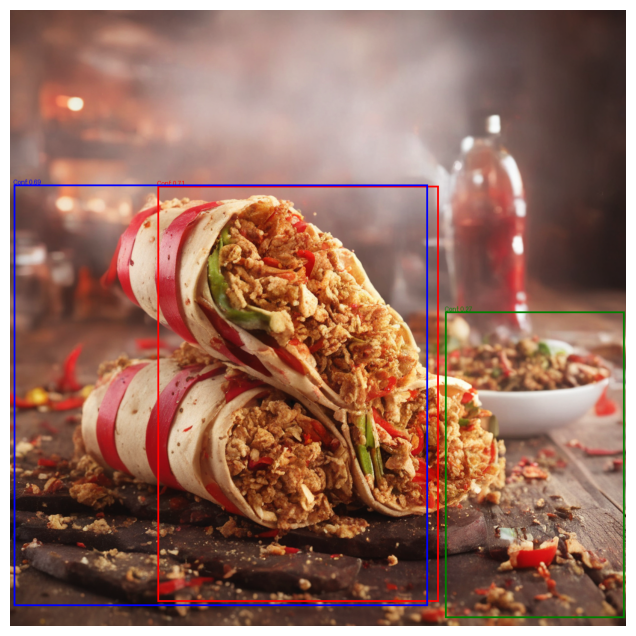

Box 1: Coordinates (245, 292, 712, 983), Confidence: 0.7083479762077332
Box 2: Coordinates (6, 290, 694, 990), Confidence: 0.6856239438056946
Box 3: Coordinates (723, 501, 1021, 1010), Confidence: 0.27340272068977356

----------YOLO RESULTS END---------------

{'content': 'Hello FAM!', 'font': 'BebasNeue-Regular.ttf', 'font_size': 60, 'position': 'top', 'text_color': 'black', 'text_type': 'promotion'}
black
Hello FAM!

 this is the elementHello FAM!
 
this is the text elements 
[{'content': 'Hello FAM!', 'font_size': 60, 'font_color': 'black', 'font': 'BebasNeue-Regular.ttf', 'top_left': (476.0, 153), 'width': 70.0, 'height': 34}]

----------JSON ELEMENTS----------
[{'content': 'Hello FAM!', 'font_size': 60, 'font_color': 'black', 'font': 'BebasNeue-Regular.ttf', 'top_left': (476.0, 153), 'width': 70.0, 'height': 34}]

----------JSON ELEMENTS END----------


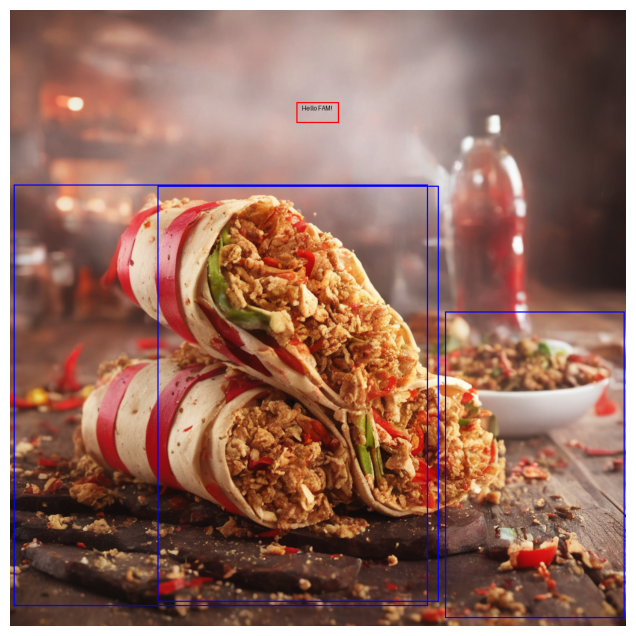

In [ ]:
# Convert endpoints to Flask routes
@VocalCraft.route('/transcribe', methods=['POST'])
def transcribe_audio():
    if 'file' not in request.files:
        return jsonify({'error': 'No file provided'}), 400

    file = request.files['file']
    with tempfile.TemporaryDirectory() as tmpdirname:
        try:
            input_path = os.path.join(tmpdirname, secure_filename(file.filename))
            output_path = os.path.join(tmpdirname, "converted.wav")
            file.save(input_path)
            logger.info(f"Saved uploaded file to '{input_path}'.")

            if not input_path.lower().endswith(".wav"):
                convert_to_wav(input_path, output_path)
                wav_path = output_path
            else:
                wav_path = input_path
                logger.info(f"No conversion needed for '{wav_path}'.")

            transcription = VocalCraft.asr(wav_path)
            logger.info(f"Transcription successful for '{wav_path}'.")
            logger.info(f"The transcribed text is: {transcription['text']}")
            return jsonify({"transcription": transcription['text']})

        except Exception as e:
            logger.error(f"Error during transcription: {e}")
            return jsonify({'error': str(e)}), 500


@VocalCraft.route('/ner', methods=['POST'])
def ner_api():
    """
    API endpoint for Named Entity Recognition (NER)
    """
    try:
        data = request.get_json()
        if not data or 'prompt' not in data:
            return jsonify({'error': 'No prompt provided'}), 400

        result = NER(data['prompt'])
        return jsonify(result)

    except Exception as e:
        logger.error(f"Error in NER processing: {e}")
        return jsonify({'error': str(e)}), 500


@VocalCraft.route('/generate_ner', methods=['POST'])
def generate_ner():
    try:
        data = request.get_json()
        if not data or 'NER' not in data or 'user_input' not in data:
            return jsonify({'error': 'Missing required fields'}), 400

        result = recreate_prompt_with_llm(data['NER'], data['user_input'], LLM)
        return jsonify(result)

    except Exception as e:
        logger.error(f"Error in /generate_ner endpoint: {e}")
        return jsonify({'error': str(e)}), 500



@VocalCraft.route('/generate_image', methods=['POST'])
def generate_image():
    try:
        data = request.get_json()
        if not data or 'old_prompt' not in data:
            return jsonify({'error': 'Missing required field (old_prompt)'}), 400
        
        # Extract old_prompt and create NER data
        old_prompt = data.pop('old_prompt')  # Remove and store old_prompt
        ner_data = data  # The remaining data is the NER structure


        print("\n-------------OLD PROMPT----------------")
        print(f"old_prompt type: {type(old_prompt)}")
        print(old_prompt)
        print("\n-------------OLD PROMPT END----------------")
        
        print("\n---------------NER DATA--------------")
        print(f"ner data type: {type(ner_data)}")
        print(ner_data)
        print("\n---------------NER DATA END--------------")

        

        # Generate new prompt using recreate_prompt_with_llm
        new_prompt = recreate_prompt_with_llm(ner_data, old_prompt, LLM)
        print("\n-------------NEW GENERATED PROMPT-------------")
        print(new_prompt)
        print("\n-------------NEW GENERATED PROMPT END-------------")
        
        
        logger.info(f"Generated new prompt: {new_prompt}")

        # Generate the image using the new prompt
        image = pipe(prompt=new_prompt, num_inference_steps=50).images[0]

        # Save the image to a BytesIO object
        with BytesIO() as img_byte_arr:
            image.save(img_byte_arr, format="PNG")
            img_byte_arr.seek(0)
            image_data = img_byte_arr.read()
            
        print("\n----------YOLO RESULTS---------------\n")
        # Run inference
        yolo_results = get_yolo_results(image, model)
        print("\n----------YOLO RESULTS END---------------\n")

        result_image, text_elements_info = paste_text_on_image(image, ner_data, yolo_results, show_grid=False)

        print("\n----------JSON ELEMENTS----------")
        print(text_elements_info)
        print("\n----------JSON ELEMENTS END----------")
        
        plt.figure(figsize=(12, 8))
        plt.imshow(result_image)
        plt.axis('off')
        plt.show()

        # Encode the image data to base64
        image_base64 = base64.b64encode(image_data).decode("utf-8")
        return jsonify({
            "message": "Image generated successfully",
            "image": image_base64,
            "prompt_used": new_prompt,
            "text_elements": text_elements_info
        })

    except Exception as e:
        logger.error(f"Error generating image: {e}")
        return jsonify({'error': str(e)}), 500

@VocalCraft.route('/print_string', methods=['POST'])
def print_string():
    data = request.get_json()
    if not data or 'string' not in data:
        return jsonify({'error': 'No string provided'}), 400

    input_string = data['string']
    print(f"Received string: {input_string}")
    return jsonify({'message': 'String received and printed', 'string': input_string}), 200


if __name__ == '__main__':
  # Setup ngrok tunnel and run the app
    public_url = ngrok.connect(addr=5000, proto="http", domain="exotic-crab-miserably.ngrok-free.app")
    print("Custom Domain URL:", public_url)
    VocalCraft.run(port=5000)

In [ ]:
# from flask import Flask, request, jsonify
# from pyngrok import ngrok

# # Flask app setup
# app = Flask(__name__)

# @app.route('/')
# def home():
#     return "Hello World in Python Flask Era"

# @app.route('/print_string', methods=['POST'])
# def print_string():
#     data = request.get_json()
#     if not data or 'string' not in data:
#         return jsonify({'error': 'No string provided'}), 400

#     input_string = data['string']
#     print(f"Received string: {input_string}")
#     return jsonify({'message': 'String received and printed', 'string': input_string}), 200

# # Ngrok setup
# # Provide your reserved domain as `domain`
# public_url = ngrok.connect(addr=5000, proto="http", domain="exotic-crab-miserably.ngrok-free.app")
# print("Custom Domain URL:", public_url)

# # Run Flask app
# if __name__ == '__main__':
#     app.run(port=5000)